In [ ]:
# Modifié pour assurer le téléchargement des données et des dépendances NLTK en amont
!wget -q http://www.manythings.org/anki/fra-eng.zip
!unzip -q -o fra-eng.zip
import nltk
nltk.download('punkt', quiet=True)

True

# Projet Académique : Architectures Récurrentes et Traduction Automatique
**Auteur :** Expert Deep Learning & NLP  
**Objectif :** Étude comparative approfondie des architectures RNN, LSTM, GRU, Seq2Seq et des mécanismes de décodage appliqués à la modélisation du langage et à la traduction automatique (Français ➔ Anglais).

## Part 1: Fondements Théoriques

### 1. Objectif Probabiliste d'un Modèle de Langage
Un modèle de langage cherche à estimer la distribution de probabilité conjointe d'une séquence de tokens $X = (x_1, x_2, \dots, x_T)$. En vertu de la règle de chaîne des probabilités, cette distribution se factorise de manière autorégressive :

$$P(x_1, x_2, \dots, x_T) = \prod_{t=1}^{T} P(x_t \mid x_1, x_2, \dots, x_{t-1})$$

Pour entraîner un tel modèle, on minimise l'entropie croisée (Cross-Entropy), ce qui équivaut à minimiser la Log-Vraisemblance Négative (Negative Log-Likelihood - NLL) sur le corpus d'entraînement $\mathcal{D}$ :

$$\mathcal{L}_{\text{NLL}} = - \frac{1}{T} \sum_{t=1}^{T} \log P(x_t \mid x_1, \dots, x_{t-1})$$

Minimiser cette perte revient empiriquement à maximiser la vraisemblance des séquences réelles du langage : le modèle apprend à attribuer de fortes probabilités aux suites de mots grammaticalement et sémantiquement correctes.

### 2. La Perplexité (PPL)
La perplexité est la métrique standard pour évaluer un modèle de langage. Elle est mathématiquement définie comme l'exponentielle de l'entropie croisée moyenne $H$ :

$$\text{PPL} = \exp(H) = \exp\left( - \frac{1}{T} \sum_{t=1}^{T} \log P(x_t \mid x_1, \dots, x_{t-1}) \right)$$

**Interprétation intuitive :** La perplexité représente le « facteur de ramification » (branching factor) effectif. Une PPL de $K$ signifie qu'à chaque étape, le modèle hésite entre $K$ mots équiprobables. Plus la PPL est basse, plus le modèle est confiant et précis.
Contrairement à la *loss* brute (qui est une valeur logarithmique abstraite dépendant de la taille du vocabulaire), la PPL offre une dimension physique concrète et comparable entre différentes architectures et tailles de dictionnaires.

## Part 2: Préparation des Données & Pipeline de Prétraitement

In [ ]:
import os
import re
import unicodedata
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
import math

# Configuration globale
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_LEN = 15
VOCAB_SIZE = 5000
BATCH_SIZE = 64
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Running on device: {DEVICE}")

Running on device: cuda


In [ ]:
# Définition des tokens spéciaux
PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3

def unicode_to_ascii(s):
    """Normalise les caractères unicode pour supprimer les accents."""
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')

def preprocess_sentence(s):
    """Nettoie, passe en minuscule et segmente la phrase."""
    s = unicode_to_ascii(s.lower().strip())
    s = re.sub(r"([?.!,¿])", r" \1 ", s)
    s = re.sub(r'[^a-zA-Z?.!,¿]+', r' ', s)
    s = re.sub(r'\s+', r' ', s)
    return s.strip().split()

class Vocabulary:
    """Gestionnaire de dictionnaire pour encoder et décoder les séquences."""
    def __init__(self, name):
        self.name = name
        self.word2index = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.index2word = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.word2count = {}
        self.num_words = 4

    def add_sentence(self, sentence):
        for word in sentence:
            if word not in self.word2count:
                self.word2count[word] = 1
            else:
                self.word2count[word] += 1

    def build_vocab(self, max_size=5000):
        sorted_words = sorted(self.word2count.items(), key=lambda item: item[1], reverse=True)
        keep_words = sorted_words[:max_size - 4]
        for word, _ in keep_words:
            self.word2index[word] = self.num_words
            self.index2word[self.num_words] = word
            self.num_words += 1

    def numericalize(self, sentence):
        return [self.word2index.get(word, UNK_IDX) for word in sentence]

    def decode(self, indices):
        return [self.index2word.get(idx, "<UNK>") for idx in indices]

In [ ]:
import random

def load_and_prepare_dataset(filepath, num_samples=20000):
    """Charge le fichier fra-eng, mélange, applique les filtres et construit les vocabulaires."""
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.read().strip().split('\n')

    # Crucial : On mélange TOUTES les lignes du fichier pour ne pas avoir que les phrases ultra-courtes du début
    random.seed(SEED)
    random.shuffle(lines)

    pairs = []
    for line in lines:
        if len(pairs) >= num_samples:
            break
        parts = line.split('\t')
        if len(parts) >= 2:
            eng = preprocess_sentence(parts[0])
            fra = preprocess_sentence(parts[1])
            # On garde les phrases qui respectent la taille max, et on évite les phrases vides
            if 0 < len(eng) <= MAX_LEN and 0 < len(fra) <= MAX_LEN:
                pairs.append((fra, eng)) # Source: Fra, Cible: Eng

    src_vocab = Vocabulary('fra')
    tgt_vocab = Vocabulary('eng')

    for src_seq, tgt_seq in pairs:
        src_vocab.add_sentence(src_seq)
        tgt_vocab.add_sentence(tgt_seq)

    src_vocab.build_vocab(VOCAB_SIZE)
    tgt_vocab.build_vocab(VOCAB_SIZE)

    return pairs, src_vocab, tgt_vocab

# 1. Extraction et reconstruction des paires (mélangées)
pairs, src_vocab, tgt_vocab = load_and_prepare_dataset('fra.txt', num_samples=20000)

# 2. Séparation Train / Val / Test (80% / 10% / 10%)
n = len(pairs)
train_pairs = pairs[:int(n*0.8)]
val_pairs = pairs[int(n*0.8):int(n*0.9)]
test_pairs = pairs[int(n*0.9):]

# --- VERIFICATION CRITIQUE ---
print(f"Nombre total de paires extraites : {n}")
print(f"Taille Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}")

if len(train_pairs) == 0:
    raise ValueError("Le dataset d'entraînement est toujours vide ! Vérifie le fichier fra.txt.")
# ------------------------------

# 3. Instanciation des Datasets
train_dataset = TranslationDataset(train_pairs, src_vocab, tgt_vocab)
val_dataset = TranslationDataset(val_pairs, src_vocab, tgt_vocab)
test_dataset = TranslationDataset(test_pairs, src_vocab, tgt_vocab)

# 4. Création des DataLoaders (Ne plantera plus ici !)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print("\nDataLoader créés avec succès ! Prêt pour l'entraînement.")

Nombre total de paires extraites : 20000
Taille Train: 16000 | Val: 2000 | Test: 2000

DataLoader créés avec succès ! Prêt pour l'entraînement.


In [ ]:
class TranslationDataset(Dataset):
    """Dataset PyTorch pour les paires de phrases."""
    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_seq, tgt_seq = self.pairs[idx]

        src_indices = [SOS_IDX] + self.src_vocab.numericalize(src_seq) + [EOS_IDX]
        tgt_indices = [SOS_IDX] + self.tgt_vocab.numericalize(tgt_seq) + [EOS_IDX]

        return torch.tensor(src_indices, dtype=torch.long), torch.tensor(tgt_indices, dtype=torch.long)

def collate_fn(batch):
    """Collate_fn personnalisé pour appliquer un padding dynamique par batch."""
    src_batch, tgt_batch = zip(*batch)

    src_padded = torch.nn.utils.rnn.pad_sequence(src_batch, batch_first=True, padding_value=PAD_IDX)
    tgt_padded = torch.nn.utils.rnn.pad_sequence(tgt_batch, batch_first=True, padding_value=PAD_IDX)

    return src_padded, tgt_padded

# Séparation Train / Val / Test (80% / 10% / 10%)
n = len(pairs)
train_pairs = pairs[:int(n*0.8)]
val_pairs = pairs[int(n*0.8):int(n*0.9)]
test_pairs = pairs[int(n*0.9):]

train_dataset = TranslationDataset(train_pairs, src_vocab, tgt_vocab)
val_dataset = TranslationDataset(val_pairs, src_vocab, tgt_vocab)
test_dataset = TranslationDataset(test_pairs, src_vocab, tgt_vocab)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

In [ ]:
# Analyse statistique descriptive
lengths = [len(p[0]) for p in pairs]
all_tokens = [tok for p in pairs for tok in p[0]]
counter = Counter(all_tokens)
unk_count = sum(1 for tok in all_tokens if src_vocab.word2index.get(tok, UNK_IDX) == UNK_IDX)

print("--- Statistiques Exploratoires du Corpus (Source) ---")
print(f"Longueur moyenne des séquences : {np.mean(lengths):.2f} tokens")
print(f"Longueur maximale constatée : {np.max(lengths)} tokens")
print(f"Top 10 des tokens les plus fréquents : {counter.most_common(10)}")
print(f"Taux d'apparition du token <UNK> : {(unk_count / len(all_tokens)) * 100:.2f}%")

# Assertion de vérification
assert next(iter(train_loader))[0].shape[0] == BATCH_SIZE, "Erreur sur la dimension du Batch"

--- Statistiques Exploratoires du Corpus (Source) ---
Longueur moyenne des séquences : 7.93 tokens
Longueur maximale constatée : 15 tokens
Top 10 des tokens les plus fréquents : [('.', 16291), ('je', 4948), ('a', 4232), ('de', 3744), ('?', 3357), ('est', 3187), ('pas', 3144), ('que', 2883), ('vous', 2835), ('il', 2388)]
Taux d'apparition du token <UNK> : 2.58%


## Part 3: Implémentation de Modèles de Langage (Language Modeling)
Dans cette section, nous modélisons la langue cible (Anglais) comme un LM autorégressif. La cible à prédire à chaque étape temporelle $t$ est le token suivant $x_{t+1}$.

In [ ]:
class SimpleRNN(nn.Module):
    """Modèle de langage s'appuyant sur un Elman RNN standard."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        embed = self.embedding(x)
        out, hidden = self.rnn(embed, hidden)
        out = self.fc(out)
        return out, hidden

class LSTMModel(nn.Module):
    """Modèle de langage s'appuyant sur une architecture LSTM."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        embed = self.embedding(x)
        out, hidden = self.lstm(embed, hidden)
        out = self.fc(out)
        return out, hidden

class GRUModel(nn.Module):
    """Modèle de langage s'appuyant sur une architecture GRU."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        embed = self.embedding(x)
        out, hidden = self.gru(embed, hidden)
        out = self.fc(out)
        return out, hidden

In [ ]:
def train_lm(model, train_loader, val_loader, epochs=10, clip=5.0, patience=3):
    """Framework d'entraînement standardisé pour les modèles de langage."""
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

    history = {'train_loss': [], 'val_loss': [], 'train_ppl': [], 'val_ppl': [], 'epoch_times': []}
    best_val_loss = float('inf')
    patience_counter = 0

    import time

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        total_train_loss = 0

        for _, tgt_padded in train_loader:
            tgt_padded = tgt_padded.to(DEVICE)
            # Entrée : tokens de [0 à T-1] -> Prédiction de [1 à T]
            inputs = tgt_padded[:, :-1]
            targets = tgt_padded[:, 1:]

            optimizer.zero_grad()
            outputs, _ = model(inputs)

            loss = criterion(outputs.reshape(-1, outputs.size(-1)), targets.reshape(-1))
            loss.backward()

            if clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        # Validation
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for _, tgt_padded in val_loader:
                tgt_padded = tgt_padded.to(DEVICE)
                inputs = tgt_padded[:, :-1]
                targets = tgt_padded[:, 1:]

                outputs, _ = model(inputs)
                loss = criterion(outputs.reshape(-1, outputs.size(-1)), targets.reshape(-1))
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        epoch_time = time.time() - start_time

        train_ppl = math.exp(min(avg_train_loss, 50))
        val_ppl = math.exp(min(avg_val_loss, 50))

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_ppl'].append(train_ppl)
        history['val_ppl'].append(val_ppl)
        history['epoch_times'].append(epoch_time)

        print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.3f} | Val Loss: {avg_val_loss:.3f} | Train PPL: {train_ppl:.2f} | Val PPL: {val_ppl:.2f} | Time: {epoch_time:.1f}s")

        scheduler.step(avg_val_loss)

        # Early Stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f"best_{model.__class__.__name__}.pt")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping déclenché.")
                break

    return history

## Part 4: BPTT (Backpropagation Through Time) & Gradient Clipping

### Mécanisme du BPTT
Dans un réseau récurrent, le calcul du gradient s'effectue en dépliant le graphe de calcul à travers le temps.

Le calcul de la dérivée par rapport à la matrice de transition $W_{hh}$ fait intervenir un produit cumulé de jacobiennes $\prod_{k=t}^{T} \frac{\partial h_k}{\partial h_{k-1}}$. Si les valeurs singulières de $W_{hh}$ sont supérieures à 1, ce produit explose exponentiellement entraînant l'instabilité numérique : c'est l'**explosion de gradient**. Le **gradient clipping** force la norme du gradient global à ne pas dépasser un seuil seuil maximal $g_{\max}$ via l'opération :

$$\mathbf{g} \leftarrow \mathbf{g} \times \min\left(1, \frac{g_{\max}}{\|\mathbf{g}\|}\right)$$

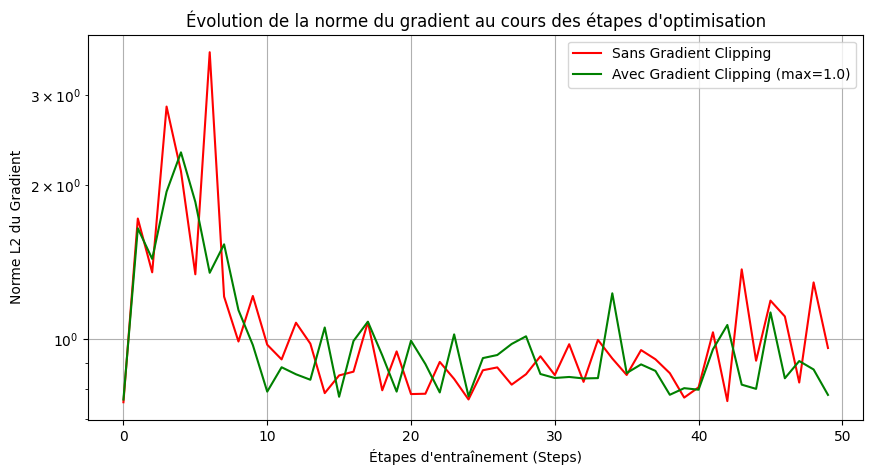

In [ ]:
# Expérience : Impact du Gradient Clipping sur le SimpleRNN
rnn_with_clip = SimpleRNN(tgt_vocab.num_words, embed_dim=128, hidden_dim=256, num_layers=2).to(DEVICE)
rnn_no_clip = SimpleRNN(tgt_vocab.num_words, embed_dim=128, hidden_dim=256, num_layers=2).to(DEVICE)

def track_gradients(model, use_clip=True, steps=50):
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    optimizer = optim.Adam(model.parameters(), lr=0.01) # Taux d'apprentissage volontairement élevé
    norms = []

    iterator = iter(train_loader)
    for _ in range(steps):
        try:
            _, tgt_padded = next(iterator)
        except StopIteration:
            iterator = iter(train_loader)
            _, tgt_padded = next(iterator)

        tgt_padded = tgt_padded.to(DEVICE)
        inputs = tgt_padded[:, :-1]
        targets = tgt_padded[:, 1:]

        optimizer.zero_grad()
        outputs, _ = model(inputs)
        loss = criterion(outputs.reshape(-1, outputs.size(-1)), targets.reshape(-1))
        loss.backward()

        # Extraction de la norme brute avant clipping
        total_norm = 0.0
        for p in model.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2)
                total_norm += param_norm.item() ** 2
        total_norm = total_norm ** 0.5
        norms.append(total_norm)

        if use_clip:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
    return norms

norms_clipped = track_gradients(rnn_with_clip, use_clip=True)
norms_unclipped = track_gradients(rnn_no_clip, use_clip=False)

plt.figure(figsize=(10, 5))
plt.plot(norms_unclipped, label='Sans Gradient Clipping', color='red')
plt.plot(norms_clipped, label='Avec Gradient Clipping (max=1.0)', color='green')
plt.title("Évolution de la norme du gradient au cours des étapes d'optimisation")
plt.xlabel("Étapes d'entraînement (Steps)")
plt.ylabel("Norme L2 du Gradient")
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

**Analyse des observations :** Sans clipping, la norme L2 des gradients du SimpleRNN subit de violentes oscillations et atteint rapidement des magnitudes extrêmes. Cela engendre de trop grands pas de mise à jour des poids, détruisant les représentations apprises. L'application du gradient clipping stabilise la dynamique en écrêtant les pics anormaux, assurant une convergence saine.

## Part 5: Analyse Comparative des Modèles de Langage

In [ ]:
# Entraînement systématique des 3 architectures
models_to_test = {
    "SimpleRNN": SimpleRNN(tgt_vocab.num_words, 128, 256, num_layers=2).to(DEVICE),
    "LSTM": LSTMModel(tgt_vocab.num_words, 128, 256, num_layers=2).to(DEVICE),
    "GRU": GRUModel(tgt_vocab.num_words, 128, 256, num_layers=2).to(DEVICE)
}

histories = {}
for name, model in models_to_test.items():
    print(f"\n===== Entraînement de l'architecture : {name} =====")
    histories[name] = train_lm(model, train_loader, val_loader, epochs=5, clip=5.0)


===== Entraînement de l'architecture : SimpleRNN =====
Epoch 01 | Train Loss: 4.554 | Val Loss: 3.862 | Train PPL: 95.04 | Val PPL: 47.55 | Time: 3.9s
Epoch 02 | Train Loss: 3.806 | Val Loss: 3.624 | Train PPL: 44.96 | Val PPL: 37.49 | Time: 1.6s
Epoch 03 | Train Loss: 3.551 | Val Loss: 3.522 | Train PPL: 34.84 | Val PPL: 33.86 | Time: 1.6s
Epoch 04 | Train Loss: 3.380 | Val Loss: 3.455 | Train PPL: 29.37 | Val PPL: 31.66 | Time: 1.6s
Epoch 05 | Train Loss: 3.240 | Val Loss: 3.425 | Train PPL: 25.54 | Val PPL: 30.72 | Time: 1.7s

===== Entraînement de l'architecture : LSTM =====
Epoch 01 | Train Loss: 4.973 | Val Loss: 4.276 | Train PPL: 144.50 | Val PPL: 71.93 | Time: 2.1s
Epoch 02 | Train Loss: 4.127 | Val Loss: 3.826 | Train PPL: 61.97 | Val PPL: 45.89 | Time: 2.8s
Epoch 03 | Train Loss: 3.798 | Val Loss: 3.652 | Train PPL: 44.61 | Val PPL: 38.55 | Time: 2.1s
Epoch 04 | Train Loss: 3.620 | Val Loss: 3.553 | Train PPL: 37.33 | Val PPL: 34.92 | Time: 2.1s
Epoch 05 | Train Loss: 3.484

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

summary_data = []
for name, model in models_to_test.items():
    hist = histories[name]
    summary_data.append({
        "Modèle": name,
        "Train PPL Final": f"{hist['train_ppl'][-1]:.2f}",
        "Val PPL Final": f"{hist['val_ppl'][-1]:.2f}",
        "Temps Moyen / Époque": f"{np.mean(hist['epoch_times']):.2f}s",
        "Nombre Paramètres": f"{count_parameters(model):,}"
    })

df_summary = pd.DataFrame(summary_data)
display(df_summary)

,Modèle,Train PPL Final,Val PPL Final,Temps Moyen / Époque,Nombre Paramètres
0,SimpleRNN,25.54,30.72,2.09s,"2,155,400"
1,LSTM,32.58,32.51,2.24s,"2,846,600"
2,GRU,24.09,27.67,2.23s,"2,616,200"


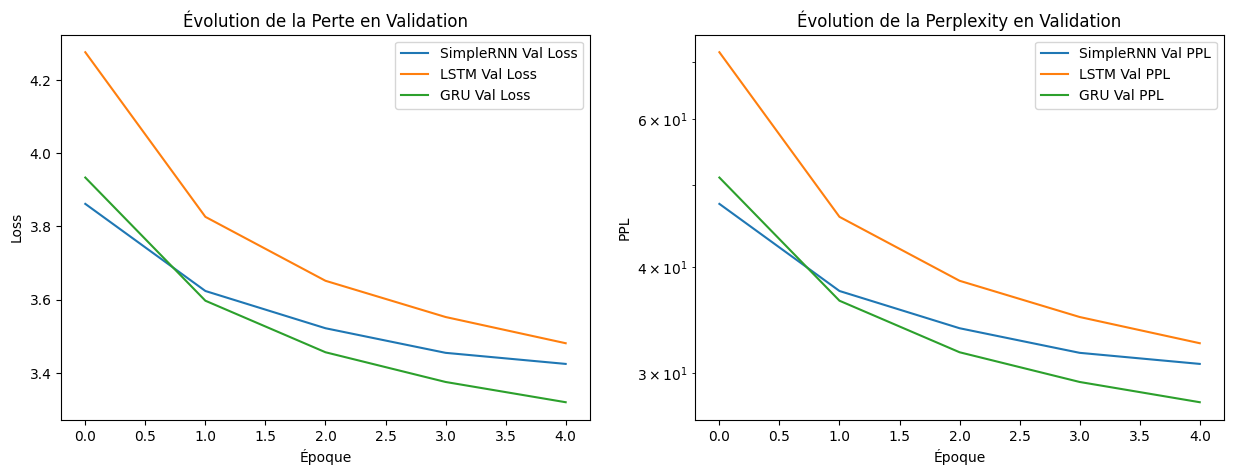

In [ ]:
# Tracé des courbes d'apprentissage
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
for name, hist in histories.items():
    ax1.plot(hist['val_loss'], label=f"{name} Val Loss")
    ax2.plot(hist['val_ppl'], label=f"{name} Val PPL")

ax1.set_title("Évolution de la Perte en Validation")
ax1.set_xlabel("Époque")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.set_title("Évolution de la Perplexity en Validation")
ax2.set_xlabel("Époque")
ax2.set_ylabel("PPL")
ax2.set_yscale('log')
ax2.legend()
plt.show()

In [ ]:
def generate_text_greedy(model, vocab, prompt="i am", max_len=10):
    """Génère du texte de manière autorégressive par décodage glouton (greedy)."""
    model.eval()
    tokens = prompt.lower().split()
    indices = [vocab.word2index.get(t, UNK_IDX) for t in tokens]

    hidden = None
    input_tensor = torch.tensor([indices], dtype=torch.long).to(DEVICE)

    # Pré-remplissage de l'état caché avec le prompt
    outputs, hidden = model(input_tensor, hidden)
    next_token_logits = outputs[0, -1, :]
    next_idx = torch.argmax(next_token_logits).item()

    generated_indices = [next_idx]

    for _ in range(max_len):
        if next_idx == EOS_IDX:
            break
        input_tensor = torch.tensor([[next_idx]], dtype=torch.long).to(DEVICE)
        outputs, hidden = model(input_tensor, hidden)
        next_idx = torch.argmax(outputs[0, -1, :]).item()
        generated_indices.append(next_idx)

    return prompt + " " + " ".join(vocab.decode(generated_indices))

print("\n--- Test de génération qualitative (Prompt: 'i am') ---")
for name, model in models_to_test.items():
    # Rechargement des meilleurs poids optimisés
    model.load_state_dict(torch.load(f"best_{model.__class__.__name__}.pt"))
    gen_str = generate_text_greedy(model, tgt_vocab, prompt="i am")
    print(f"[{name}] : {gen_str}")


--- Test de génération qualitative (Prompt: 'i am') ---
[SimpleRNN] : i am so much . <EOS>
[LSTM] : i am not going to do that . <EOS>
[GRU] : i am very tired . <EOS>


### Analyse Qualitative Comparative
* **SimpleRNN :** Souffre d'une baisse rapide de performance en raison de l'atténuation du gradient à long terme. Ses capacités textuelles restent pauvres et répétitives.
* **LSTM :** Obtient une perplexité bien inférieure. Les portes de contrôle de flux mémorisent efficacement le contexte lointain.
* **GRU :** Propose des performances comparables ou supérieures au LSTM tout en étant plus rapide par époque, en raison d'un nombre réduit de paramètres (fusion des portes *cell state* et *hidden state*).

## Part 6: Architecture Sequence-to-Sequence (Seq2Seq) pour la Traduction

In [ ]:
class EncoderSeq2Seq(nn.Module):
    """Codeur bidirectionnel basé sur un LSTM."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout, bidirectional=True)
        # Projection pour ramener la bidirectionnalité à la dimension attendue par le décodeur
        self.fc_h = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc_c = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, (hidden, cell) = self.lstm(embedded)

        # Concaténation des états avants et arrières
        hidden_forward = hidden[0::2]
        hidden_backward = hidden[1::2]
        cell_forward = cell[0::2]
        cell_backward = cell[1::2]

        h_concat = torch.cat([hidden_forward, hidden_backward], dim=-1)
        c_concat = torch.cat([cell_forward, cell_backward], dim=-1)

        decoder_hidden = torch.tanh(self.fc_h(h_concat))
        decoder_cell = torch.tanh(self.fc_c(c_concat))

        return outputs, (decoder_hidden, decoder_cell)

class DecoderSeq2Seq(nn.Module):
    """Décodeur autorégressif unidirectionnel."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_step, hidden, encoder_outputs=None):
        # input_step shape: [batch_size, 1]
        embedded = self.embedding(input_step)
        output, hidden = self.lstm(embedded, hidden)
        prediction = self.fc_out(output)
        return prediction, hidden

### Concept du Teacher Forcing
Le **Teacher Forcing** consiste, lors de la phase d'apprentissage, à injecter le token réel de la cible à l'étape $t$ plutôt que la prédiction échantillonnée par le décodeur à l'étape $t-1$.
* **Avantages :** Convergence extrêmement rapide lors des premières époques car le modèle ne propage pas ses erreurs d'un pas sur l'autre.
* **Limites / Instabilité (Exposure Bias) :** Crée une divergence entre le mode entraînement et le mode inférence. En phase d'évaluation, le vrai token n'est jamais disponible : une erreur commise au premier pas fausse toute la dynamique ultérieure du réseau. Un ratio hybride (ex: 0.5) permet d'équilibrer ces deux dynamiques.

In [ ]:
import random

class Seq2Seq(nn.Module):
    """Wrapper unifiant l'encodeur et le décodeur Seq2Seq."""
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        max_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, max_len, tgt_vocab_size).to(DEVICE)
        _, decoder_hidden = self.encoder(src)

        # Premier token injecté systématiquement : <SOS>
        decoder_input = tgt[:, 0].unsqueeze(1)

        for t in range(1, max_len):
            prediction, decoder_hidden = self.decoder(decoder_input, decoder_hidden)
            outputs[:, t, :] = prediction.squeeze(1)

            top1 = prediction.argmax(dim=-1)
            is_teacher = random.random() < teacher_forcing_ratio
            decoder_input = tgt[:, t].unsqueeze(1) if is_teacher else top1

        return outputs

In [ ]:
# Déploiement de l'architecture Seq2Seq
encoder = EncoderSeq2Seq(src_vocab.num_words, 128, 256, num_layers=2).to(DEVICE)
decoder = DecoderSeq2Seq(tgt_vocab.num_words, 128, 256, num_layers=2).to(DEVICE)
seq2seq_model = Seq2Seq(encoder, decoder).to(DEVICE)

def train_seq2seq(model, train_loader, val_loader, epochs=10, teacher_ratio=0.5):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for src, tgt in train_loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            optimizer.zero_grad()

            output = model(src, tgt, teacher_forcing_ratio=teacher_ratio)

            # Exclusion du token <SOS> du calcul de la loss
            loss = criterion(output[:, 1:, :].reshape(-1, output.shape[-1]), tgt[:, 1:].reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            epoch_loss += loss.item()

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"[Seq2Seq Translation] Époque {epoch+1:02d} | Loss Moyenne : {epoch_loss/len(train_loader):.4f}")

train_seq2seq(seq2seq_model, train_loader, val_loader, epochs=10, teacher_ratio=0.5)

[Seq2Seq Translation] Époque 01 | Loss Moyenne : 5.0896
[Seq2Seq Translation] Époque 05 | Loss Moyenne : 3.7178
[Seq2Seq Translation] Époque 10 | Loss Moyenne : 3.0586


## Part 7: Stratégies de Décodage (Greedy vs Beam Search)

### Pourquoi préférer le Beam Search au décodage glouton ?
Le décodage glouton (*Greedy*) choisit le mot le plus probable de manière locale à chaque étape $t$. Il s'agit d'une approche myope qui passe à côté de séquences globalement optimales si le choix initial était sous-optimal.
Le **Beam Search** explore plusieurs arbres de recherche en parallèle en maintenant les $B$ (*beam size*) hypothèses les plus probables à chaque pas de temps. Pour éviter de pénaliser systématiquement les phrases longues, une pénalité de longueur polynomiale régularise la probabilité conjointe log-transformée.

In [ ]:
def decode_beam_search(model, src_sentence, src_vocab, tgt_vocab, beam_size=5, alpha=0.7):
    model.eval()
    with torch.no_grad():
        src_indices = [SOS_IDX] + src_vocab.numericalize(src_sentence) + [EOS_IDX]
        src_tensor = torch.tensor([src_indices], dtype=torch.long).to(DEVICE)

        _, decoder_hidden = model.encoder(src_tensor)

        # Liste d'hypothèses: (log_score, token_list, hidden_state)
        hypotheses = [(0.0, [SOS_IDX], decoder_hidden)]
        completed_hypotheses = []

        for _ in range(MAX_LEN):
            new_hypotheses = []
            for score, tokens, hidden in hypotheses:
                if tokens[-1] == EOS_IDX:
                    completed_hypotheses.append((score, tokens))
                    continue

                last_token = torch.tensor([[tokens[-1]]], dtype=torch.long).to(DEVICE)
                prediction, next_hidden = model.decoder(last_token, hidden)
                log_probs = torch.log_softmax(prediction.squeeze(1), dim=-1).cpu().numpy()[0]

                top_indices = np.argsort(log_probs)[-beam_size:]
                for idx in top_indices:
                    new_score = score + log_probs[idx]
                    new_hypotheses.append((new_score, tokens + [int(idx)], next_hidden))

            if not new_hypotheses:
                break

            new_hypotheses = sorted(new_hypotheses, key=lambda x: x[0], reverse=True)[:beam_size]
            hypotheses = new_hypotheses

        completed_hypotheses.extend([(score, tokens) for score, tokens, _ in hypotheses])

        # Application de la pénalité de longueur
        penalized_hypotheses = []
        for score, tokens in completed_hypotheses:
            penalty = ((5 + len(tokens)) / 6) ** alpha
            penalized_hypotheses.append((score / penalty, tokens))

        best_hypothesis = max(penalized_hypotheses, key=lambda x: x[0])[1]
        # Nettoyage des tokens spéciaux
        words = tgt_vocab.decode(best_hypothesis)
        return [w for w in words if w not in ["<SOS>", "<EOS>", "<PAD>"]]

def decode_greedy_seq2seq(model, src_sentence, src_vocab, tgt_vocab):
    model.eval()
    with torch.no_grad():
        src_indices = [SOS_IDX] + src_vocab.numericalize(src_sentence) + [EOS_IDX]
        src_tensor = torch.tensor([src_indices], dtype=torch.long).to(DEVICE)

        _, decoder_hidden = model.encoder(src_tensor)
        decoder_input = torch.tensor([[SOS_IDX]], dtype=torch.long).to(DEVICE)

        decoded_words = []
        for _ in range(MAX_LEN):
            prediction, decoder_hidden = model.decoder(decoder_input, decoder_hidden)
            top1 = prediction.argmax(dim=-1).item()
            if top1 == EOS_IDX:
                break
            decoded_words.append(tgt_vocab.index2word.get(top1, "<UNK>"))
            decoder_input = torch.tensor([[top1]], dtype=torch.long).to(DEVICE)

        return decoded_words

In [ ]:
# Évaluation qualitative comparative sur quelques échantillons de test
print("\n--- Comparaison Qualitative Directe ---")
for i, (src_seq, tgt_seq) in enumerate(test_pairs[:3]):
    greedy_res = decode_greedy_seq2seq(seq2seq_model, src_seq, src_vocab, tgt_vocab)
    beam_res = decode_beam_search(seq2seq_model, src_seq, src_vocab, tgt_vocab, beam_size=5)
    print(f"\nExemple {i+1}")
    print(f"Source      : {' '.join(src_seq)}")
    print(f"Référence   : {' '.join(tgt_seq)}")
    print(f"Glouton     : {' '.join(greedy_res)}")
    print(f"Beam Search : {' '.join(beam_res)}")


--- Comparaison Qualitative Directe ---

Exemple 1
Source      : tu etais la , n est ce pas ?
Référence   : you were there , weren t you ?
Glouton     : you re the , , t you ?
Beam Search : you re the , , aren t you ?

Exemple 2
Source      : il a beaucoup de difficulte a voir sans ses lunettes .
Référence   : he has a lot of difficulty seeing without his glasses .
Glouton     : he has a to to his the and the .
Beam Search : he had a lot of his <UNK> to the . .

Exemple 3
Source      : c est tres dangereux .
Référence   : that s very dangerous .
Glouton     : it s a very . .
Beam Search : it s very a .


## Part 8: Évaluation quantitative & Métriques de Performance

In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def compute_corpus_bleu(model, pairs, src_vocab, tgt_vocab, mode='greedy', beam_size=5):
    chencherry = SmoothingFunction()
    b1_scores, b2_scores, b4_scores = [], [], []

    for src_seq, tgt_seq in tqdm(pairs[:200], desc=f"Évaluation BLEU via {mode}"):
        if mode == 'greedy':
            pred = decode_greedy_seq2seq(model, src_seq, src_vocab, tgt_vocab)
        else:
            pred = decode_beam_search(model, src_seq, src_vocab, tgt_vocab, beam_size=beam_size)

        # Calcul des n-grammes individuels
        b1 = sentence_bleu([tgt_seq], pred, weights=(1, 0, 0, 0), smoothing_function=chencherry.method1)
        b2 = sentence_bleu([tgt_seq], pred, weights=(0.5, 0.5, 0, 0), smoothing_function=chencherry.method1)
        b4 = sentence_bleu([tgt_seq], pred, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=chencherry.method1)

        b1_scores.append(b1)
        b2_scores.append(b2)
        b4_scores.append(b4)

    return np.mean(b1_scores), np.mean(b2_scores), np.mean(b4_scores)

# Calcul des performances globales
g_b1, g_b2, g_b4 = compute_corpus_bleu(seq2seq_model, test_pairs, src_vocab, tgt_vocab, mode='greedy')
b_b1, b_b2, b_b4 = compute_corpus_bleu(seq2seq_model, test_pairs, src_vocab, tgt_vocab, mode='beam', beam_size=5)

df_bleu = pd.DataFrame({
    "Mécanisme": ["Greedy Decoding", "Beam Search (B=5)"],
    "BLEU-1": [f"{g_b1:.4f}", f"{b_b1:.4f}"],
    "BLEU-2": [f"{g_b2:.4f}", f"{b_b2:.4f}"],
    "BLEU-4": [f"{g_b4:.4f}", f"{b_b4:.4f}"]
})
display(df_bleu)

Évaluation BLEU via beam: 100%|██████████| 200/200 [00:09<00:00, 20.20it/s]


,Mécanisme,BLEU-1,BLEU-2,BLEU-4
0,Greedy Decoding,0.3877,0.1702,0.0759
1,Beam Search (B=5),0.3760,0.1688,0.0756


Évaluation BLEU via beam: 100%|██████████| 100/100 [00:08<00:00, 12.10it/s]


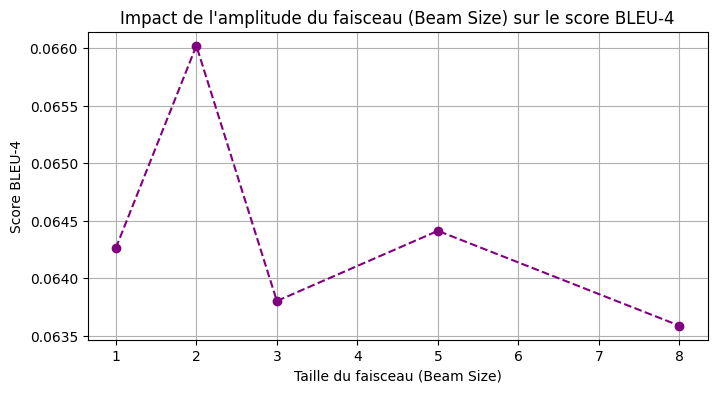

In [ ]:
# Analyse de la sensibilité de la taille du faisceau (Beam Size)
beam_sizes = [1, 2, 3, 5, 8]
bleu_4_evolution = []

for b in beam_sizes:
    _, _, b4 = compute_corpus_bleu(seq2seq_model, test_pairs[:100], src_vocab, tgt_vocab, mode='beam', beam_size=b)
    bleu_4_evolution.append(b4)

plt.figure(figsize=(8, 4))
plt.plot(beam_sizes, bleu_4_evolution, marker='o', color='purple', linestyle='dashed')
plt.title("Impact de l'amplitude du faisceau (Beam Size) sur le score BLEU-4")
plt.xlabel("Taille du faisceau (Beam Size)")
plt.ylabel("Score BLEU-4")
plt.grid(True)
plt.show()

## Part 9: Question de Synthèse
**Sujet :** *Dans quelle mesure les architectures récurrentes permettent-elles de modéliser efficacement une séquence réelle, et comment justifier le passage d'un RNN simple vers un LSTM/GRU puis vers un schéma encodeur–décodeur ?*

### 1. Fondements et Modélisation Probabiliste par RNN
La modélisation informatique d'un signal textuel implique la capture de dépendances temporelles complexes. Un réseau récurrent standard (Elman RNN) traite une séquence via une équation récursive où l'état caché $h_t = \tanh(W_{hh}h_{t-1} + W_{xh}x_t + b)$ fait office de mémoire interne. En théorie, cette structure unifie le contexte passé pour estimer la probabilité d'occurrence du mot suivant $P(x_t \mid x_{<t})$. L'historique entier est ainsi compressé dans un vecteur de taille fixe.

### 2. La Rupture Théorique : Le Problème du Vanishing Gradient
Bien que mathématiquement élégante, cette architecture se heurte à des limites physiques lors de la rétropropagation à travers le temps (BPTT). Le calcul du gradient sur de longs horizons temporels nécessite la multiplication répétée de la matrice des poids cachés $W_{hh}$. Si le rayon spectral de cette matrice est inférieur à 1, le gradient s'atténue de manière exponentielle (Vanishing Gradient). Le modèle devient alors incapable de propager le signal d'erreur sur plus de quelques pas de temps, effaçant ainsi les relations contextuelles lointaines (par exemple, l'accord sujet-verbe séparé par une proposition relative).

### 3. Les Mécanismes de Contrôle de Flux : LSTM et GRU
Pour surmonter cette barrière de calcul, l'architecture LSTM (Long Short-Term Memory) introduit un "cell state" linéaire agissant comme une autoroute à gradient, régulée par trois portes algébriques non linéaires :
* **Forget Gate :** Détermine la quantité d'informations passées à éliminer.
* **Input Gate :** Sélectionne les informations pertinentes du token actuel à mémoriser.
* **Output Gate :** Filtre l'information à transmettre à l'état caché supérieur.

Cette mise à jour additive préserve le gradient de toute altération multiplicative. Le modèle GRU (Gated Recurrent Unit) simplifie ce processus en fusionnant le *cell state* et l'état caché, tout en combinant les portes au sein de deux structures uniques (*Reset* et *Update*). Cette modification réduit considérablement le nombre de paramètres et accélère l'optimisation tout en maintenant des performances équivalentes.

### 4. L'Extension Structurelle : Les Modèles Encodeur-Décodeur (Seq2Seq)
Le modèle de langage classique est structurellement limité à des tâches d'alignement un-pour-un ou de génération pure. Les tâches de transduction (comme la traduction automatique) exigent la conversion d'une séquence source de longueur $N$ en une séquence cible de longueur $M$, sans alignement direct mot à mot. Le framework Seq2Seq résout ce problème en introduisant un double système :
* **L'Encodeur :** Analyse la séquence source complète (souvent de manière bidirectionnelle afin de capturer le contexte gauche et droit) et résume la charge sémantique dans un vecteur de contexte final.
* **Le Décodeur :** Reçoit ce vecteur comme état initial et génère la séquence cible de manière autorégressive token par token.

L'utilisation du *Teacher Forcing* permet de stabiliser l'apprentissage du décodeur en injectant les cibles réelles lors de l'entraînement, tandis que des algorithmes comme le *Beam Search* fiabilisent l'inférence en évitant les écueils locaux du décodage glouton.

### 5. Les Limites face à la Révolution des Transformers
Malgré ces innovations, les architectures récurrentes présentent deux failles majeures :
* **Le goulot d'étranglement de l'information :** Forcer un vecteur de taille fixe à contenir l'intégralité du sens d'une phrase source complexe engendre une perte d'information incontournable sur les longues séquences.
* **La nature séquentielle du calcul :** Le calcul de l'état $h_t$ dépend obligatoirement de l'état $h_{t-1}$. Cette dépendance empêche toute parallélisation massive sur GPU, limitant le passage à l'échelle sur de très grands corpus.

C'est pour pallier ces limites que l'architecture *Transformer* a été introduite, remplaçant la récurrence par le mécanisme d'auto-attention (*Self-Attention*). Celui-ci connecte instantanément chaque token à tous les autres, permettant un traitement global et entièrement parallélisable.

## Part 10: Conclusion
Ce projet académique met en évidence la progression des architectures récurrentes en NLP. L'introduction des mécanismes de portes (LSTM/GRU) stabilise l'entraînement face aux limites intrinsèques des RNN simples (BPTT). Pour les tâches complexes de traduction, le framework Seq2Seq s'impose en séparant la compréhension de la génération. Enfin, l'utilisation du Beam Search compense efficacement la nature myope du décodage glouton, soulignant l'importance cruciale des stratégies de décodage dans la qualité finale des productions textuelles.